In [1]:
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
energy_df = pd.read_csv("ukenergydata.csv")
weather_df = pd.read_csv("ukweatherdata.csv", header=0)

FileNotFoundError: [Errno 2] No such file or directory: 'ukenergydata.csv'

In [4]:
energy_df['date'] = pd.to_datetime(energy_df['SETTLEMENT_DATE'], errors='coerce')
weather_df['date'] = pd.to_datetime(weather_df['date'], errors='coerce')


NameError: name 'energy_df' is not defined

In [5]:
# Drop columns with >95% missing
energy_df = energy_df.drop(columns=energy_df.columns[energy_df.isna().mean() > 0.95])

# Forward-fill numeric columns (except SETTLEMENT_PERIOD)
numeric_cols = energy_df.select_dtypes(include='number').columns.difference(['SETTLEMENT_PERIOD'])
energy_df[numeric_cols] = energy_df[numeric_cols].fillna(method='ffill')

# Aggregate to daily
daily_energy = energy_df.groupby('date')[numeric_cols].mean().reset_index()


NameError: name 'energy_df' is not defined

In [6]:
# Drop non-numeric columns before grouping
weather_agg = weather_df.drop(columns=['location', 'wind_direction']).groupby('date').mean().reset_index()


NameError: name 'weather_df' is not defined

In [7]:
merged_df = pd.merge(daily_energy, weather_agg, on='date', how='inner')

NameError: name 'daily_energy' is not defined

In [9]:
merged_df = pd.read_csv("merged_ukdata.csv")
merged_df.head()

,date,BRITNED_FLOW,EAST_WEST_FLOW,ELECLINK_FLOW,EMBEDDED_SOLAR_CAPACITY,EMBEDDED_SOLAR_GENERATION,EMBEDDED_WIND_CAPACITY,EMBEDDED_WIND_GENERATION,ENGLAND_WALES_DEMAND,IFA2_FLOW,...,settlement_period,tsd,viking_flow,min_temp °c,max_temp °c,rain mm,humidity %,cloud_cover %,wind_speed km/h,wind_direction_numerical
0,2009-01-01,0.0,0.0,NaN,0.0,0.0,1403.0,65.666667,33527.729167,0.0,...,NaN,NaN,NaN,-1.988072,1.886680,0.114115,83.870775,32.479125,10.300199,94.160040
1,2009-01-02,0.0,0.0,NaN,0.0,0.0,1403.0,292.395833,36087.083333,0.0,...,NaN,NaN,NaN,-0.705765,3.755467,0.046918,88.558648,43.236581,13.721670,80.382704
2,2009-01-03,0.0,0.0,NaN,0.0,0.0,1403.0,185.375000,35530.187500,0.0,...,NaN,NaN,NaN,-2.089463,2.667992,0.102386,80.930417,25.284294,10.890656,154.502982
3,2009-01-04,0.0,0.0,NaN,0.0,0.0,1403.0,330.354167,35889.770833,0.0,...,NaN,NaN,NaN,-2.043738,1.956262,0.517296,83.399602,58.314115,11.992048,261.098410
4,2009-01-05,0.0,0.0,NaN,0.0,0.0,1403.0,508.916667,41006.854167,0.0,...,NaN,NaN,NaN,-1.789264,2.685885,0.772763,84.389662,37.079523,17.214712,122.251491


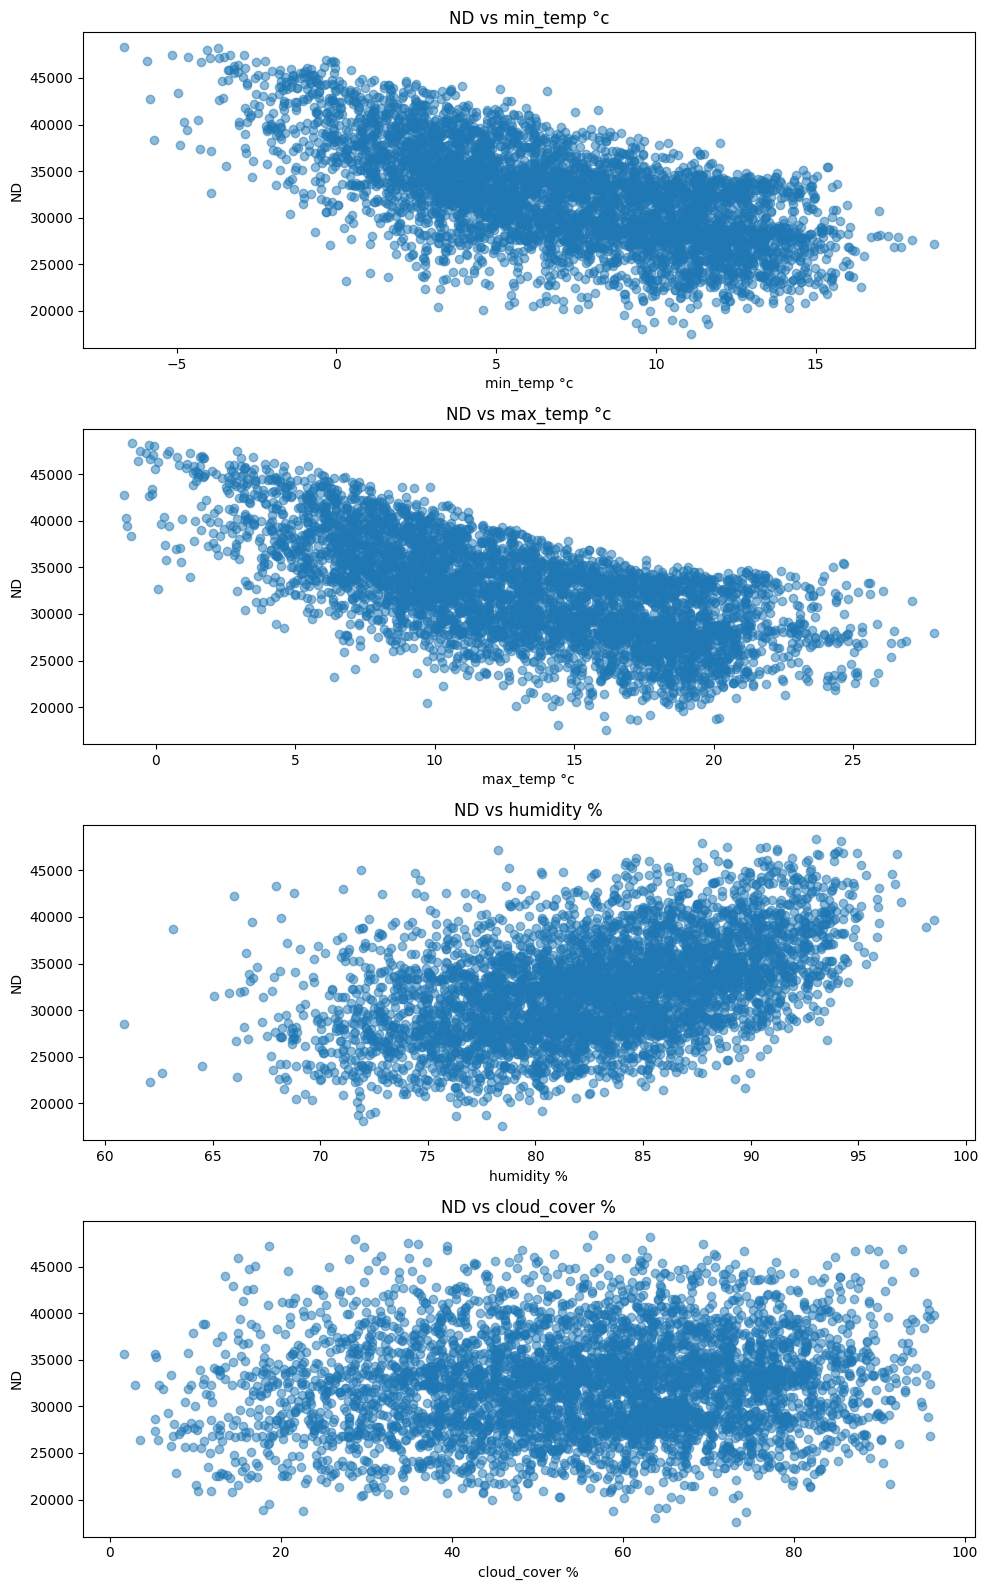

In [9]:
features = ['min_temp °c', 'max_temp °c', 'humidity %', 'cloud_cover %']
target = 'ND'  # or whichever demand column you're using

fig, axes = plt.subplots(nrows=len(features), figsize=(10, 4 * len(features)))

for i, feature in enumerate(features):
    axes[i].scatter(merged_df[feature], merged_df[target], alpha=0.5)
    axes[i].set_title(f"{target} vs {feature}")
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel(target)

plt.tight_layout()
plt.show()